In [2]:
import sklearn
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

**Please write your name below** (in case the file names get mixed up)

Paul Huguet

# Dataset

Let's load data for classification. This data is generated and does not a precise meaning: the idea will be to build intuition about what is going on with different models.

Dataset can be downloaded here: https://drive.google.com/file/d/1Sy0Ly4Xj8fzPAiPru9oFS6evgQjuNMs4/view?usp=sharing

In [3]:
# Load the dataset;
# make sure that the file is located in the same folder as the notebook
# (or change the path)
dataset = np.load("dataset.npy")

In [4]:
# Extract features and targets
X = dataset[:,:2] # features are first 2 columns
y = dataset[:,-1] # labels are last column
print(f'Shape of feature matrix: {X.shape}')

Shape of feature matrix: (300, 2)


# Data preparation

**Split the dataset into one training and one testing sets.** You can use the sklearn.model_selection.train_test_split function (but you don't have to).

We shall use the name X_train and X_test (respectively y_train and y_test) to refer to the samples (respectively labels) of these sets.

In [5]:
X_train,X_test,y_train,y_test = sklearn.model_selection.train_test_split(X,y, test_size=0.1)


## Bagging and boosting

**Fit a bagging model on the dataset, and measure your performance.**

Make sure your methodology is correct.

**Display the resulting probability heatmap**

In [6]:
print(np.sqrt(X_train.shape[0]))

16.431676725154983


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

pipeline = sklearn.pipeline.Pipeline([
    ('random_forest', RandomForestClassifier(bootstrap=True, max_samples = (X_train.shape[0]//2)))
])  

hyperparameters = {
    'random_forest__n_estimators': [50, 100, 200],
    'random_forest__max_depth': [5, 10,20],
    'random_forest__min_samples_leaf': [2, 5, 10]
}

gridsearch = GridSearchCV(pipeline, hyperparameters,cv=10)
gridsearch.fit(X_train, y_train)
best_param = gridsearch.best_params_
print(best_param)

{'random_forest__max_depth': 10, 'random_forest__min_samples_leaf': 2, 'random_forest__n_estimators': 50}


In [8]:
gridsearch.score(X_test,y_test)

0.9666666666666667

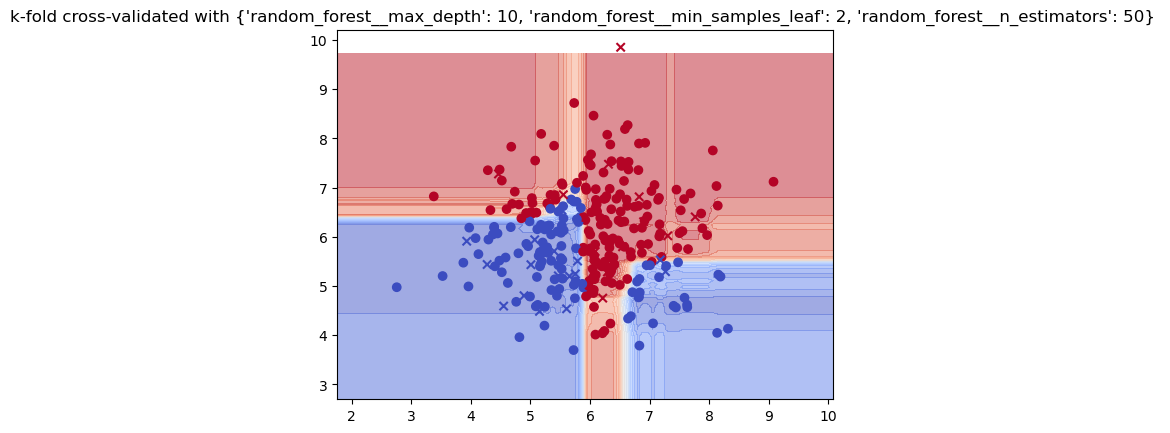

In [9]:
from sklearn.inspection import DecisionBoundaryDisplay
disp = DecisionBoundaryDisplay.from_estimator(
    gridsearch, X_train,
    response_method="predict_proba",
    cmap=plt.cm.coolwarm, # colors to use (0 is blue, 1 is red)
    alpha=0.5, # level of transparency
    levels=20 # use 20 different nuances of color
)

disp.ax_.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.coolwarm)
disp.ax_.scatter(X_test[:, 0], X_test[:, 1], c=y_test, marker='x', cmap=plt.cm.coolwarm)
plt.title(f"k-fold cross-validated with {best_param} ")
plt.show()

**Fit a boosting model on the dataset, measure the performance and display the heatmap.**

In [10]:
from sklearn.ensemble import GradientBoostingClassifier

pipeline = sklearn.pipeline.Pipeline([
    ('boosting', GradientBoostingClassifier())
])

hyperparameters = {
    'boosting__n_estimators': [50, 100, 200],
    'boosting__max_depth': [5, 10,20],
    'boosting__min_samples_leaf': [2, 5, 10]
    
    }
gridsearch_boosting = GridSearchCV(pipeline, hyperparameters,cv=10)
gridsearch_boosting.fit(X_train, y_train)
best_param_boosting = gridsearch_boosting.best_params_
print(best_param_boosting)

{'boosting__max_depth': 10, 'boosting__min_samples_leaf': 2, 'boosting__n_estimators': 100}


In [11]:
gridsearch_boosting.score(X_test,y_test)

0.9333333333333333

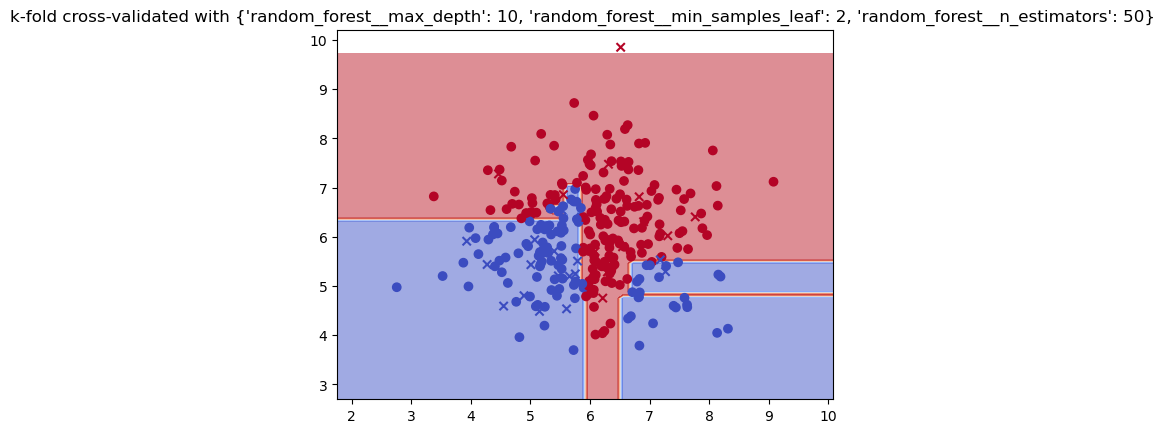

In [12]:
from sklearn.inspection import DecisionBoundaryDisplay
disp = DecisionBoundaryDisplay.from_estimator(
    gridsearch_boosting, X_train,
    response_method="predict_proba",
    cmap=plt.cm.coolwarm, # colors to use (0 is blue, 1 is red)
    alpha=0.5, # level of transparency
    levels=20 # use 20 different nuances of color
)

disp.ax_.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.coolwarm)
disp.ax_.scatter(X_test[:, 0], X_test[:, 1], c=y_test, marker='x', cmap=plt.cm.coolwarm)
plt.title(f"k-fold cross-validated with {best_param} ")
plt.show()

## Multi-class, higher dimension classification

For this part, we are going to use the MNIST dataset again. We can download a lower-dimension version of the one we used in lab 3, with images of size 8x8, using scikit-learn utility functions. Initially, values are between 0 and 16. We will normalize them to values between 0 and 1.

In [13]:
from sklearn.datasets import load_digits

In [14]:
digits = load_digits(return_X_y=False)

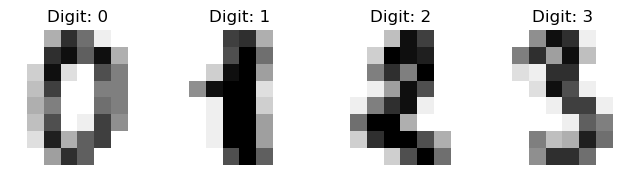

In [15]:
# Display the first 4 digits
_, axes = plt.subplots(nrows=1, ncols=4, figsize=(8, 3)) # Create 4 subplots on 1 row
for ax, x, y in zip(axes, digits.data, digits.target):
    ax.set_axis_off() # do not display scale on axes
    img = x.reshape(8,8) / 16 # resize 64 dim vector as an 8 x 8 array of pixels and scale values to 0-1
    ax.imshow(img, cmap=plt.cm.gray_r, vmin=0, vmax=1) # display image in gray scale, with values from 0 to 1
    ax.set_title(f"Digit: {y}")

We will only keep digits 1, 2 and 3 to simplify things.

In [16]:
# only keep features for which target is 1, 2, or 3 
X_123, y_123 = zip(*[(x, y) for x, y in zip(digits.data, digits.target) if y in [1,2,3]])
X_123, y_123 = np.array(X_123) / 16, np.array(y_123) # normalizing training features to values between 0 and 1
print(f"Number of samples kept: {X_123.shape[0]}")

Number of samples kept: 542


In [17]:
X_train, X_test, y_train, y_test =  sklearn.model_selection.train_test_split(X_123, y_123, test_size=0.20, random_state=42)
print(f"Training samples: {y_train.shape[0]}, test samples: {y_test.shape[0]}")

Training samples: 433, test samples: 109


**Fit a model on this multi-class dataset, and display the resulting decision boundary**

Here, we have more than 2 classes, and the dataset is not 2D: you will have to think about a solution that is a bit different from what we did in the rest of the lab.

In [18]:
gridsearch_boosting.fit(X_train, y_train)
best_param_boosting = gridsearch_boosting.best_params_
print(best_param_boosting)
print(f"accuracy of our random forest {gridsearch_boosting.score(X_test,y_test)}")


{'boosting__max_depth': 10, 'boosting__min_samples_leaf': 10, 'boosting__n_estimators': 200}
accuracy of our random forest 1.0


In [ ]:
from  sklearn.manifold import TSNE
y_predict = gridsearch_boosting.predict(X_test)
tsne = TSNE(n_components=2,random_state=1)
X_digits_tsne = tsne.fit_transform(X_train)
X_test_tsne = tsne.fit_transform(X_test)
print(X_test_tsne.shape)


ValueError: X has 64 features, but GradientBoostingClassifier is expecting 2 features as input.

In [46]:
gridsearch_2d = GridSearchCV(pipeline, hyperparameters,cv=10)
gridsearch_2d.fit(X_digits_tsne, y_train)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'boosting__max_depth': [5, 10, ...], 'boosting__min_samples_leaf': [2, 5, ...], 'boosting__n_estimators': [50, 100, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


Dans l'idée, il ne faudrait pas faire ça : réentreinner le modèle en 2D, mais plutot projetter la bondary de nD à 2D. Cependant, pour la calculer de manière naive, cela consiste à echantilloner les nD dimension et de calculer le label estimé ce qui renvient à avoir n_estimateur^nombre dimension. Même si on prend seulement 100 échantillons par coordonné, cela est numériquement important. 

c:\Users\hugue\anaconda3\envs\mlclass\lib\site-packages\sklearn\inspection\_plot\decision_boundary.py:226: UserWarning: 'cmap' is ignored in favor of 'multiclass_colors' in the multiclass case when the response method is 'decision_function' or 'predict_proba'.
  warnings.warn(
c:\Users\hugue\anaconda3\envs\mlclass\lib\site-packages\sklearn\inspection\_plot\decision_boundary.py:282: UserWarning: The following kwargs were not used by contour: 'multiclass'
  plot_func(self.xx0, self.xx1, response, cmap=cmap, **kwargs)


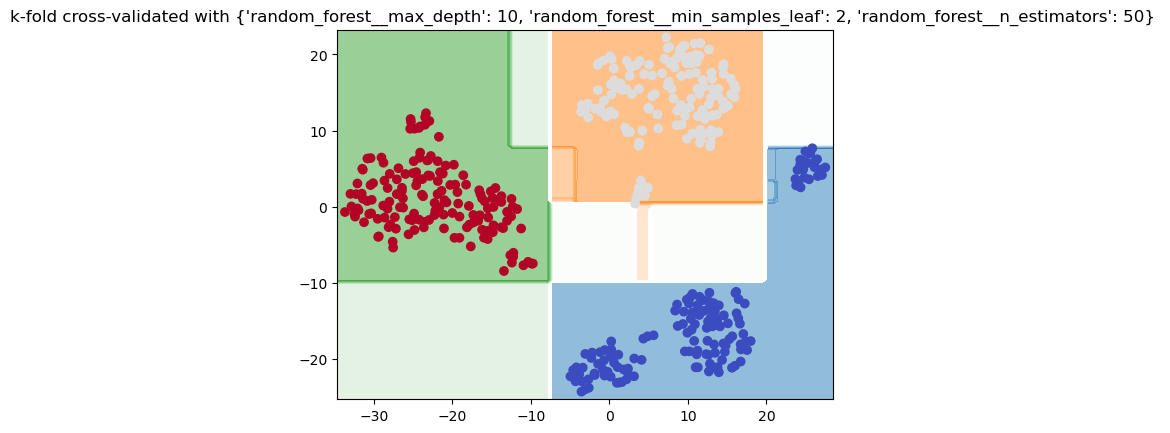

In [55]:
disp = DecisionBoundaryDisplay.from_estimator(
    gridsearch_2d, X_digits_tsne,
    response_method="predict_proba",
    cmap=plt.cm.coolwarm, # colors to use (0 is blue, 1 is red)
    alpha=0.5, # level of transparency
    levels=20, # use 20 different nuances of color
    multiclass=True
)

disp.ax_.scatter(X_digits_tsne[:, 0], X_digits_tsne[:, 1], c=y_train, cmap=plt.cm.coolwarm)
plt.title(f"k-fold cross-validated with {best_param} ")
plt.show()

Text(0.5, 1.0, 'Resultats prédits')

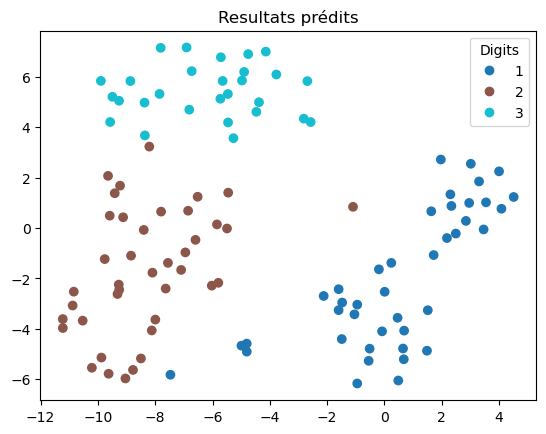

In [ ]:

scatter = plt.scatter(X_digits_tsne[:,0], X_digits_tsne[:,1], c=y_predict,cmap='tab10')
plt.legend(*scatter.legend_elements(),
                     title="Digits")
plt.title("Resultats prédits")

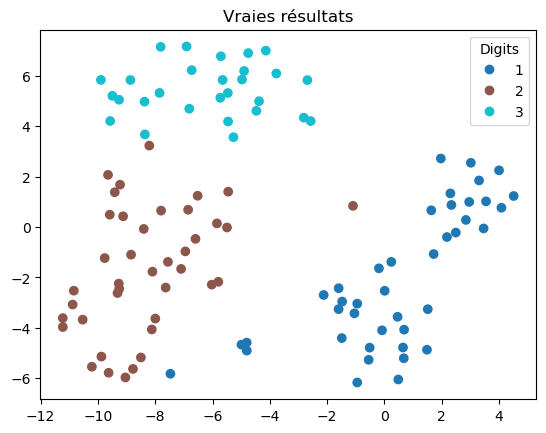

In [ ]:
plt.title("Vraies résultats")
scatter = plt.scatter(X_digits_tsne[:,0], X_digits_tsne[:,1], c=y_test,cmap='tab10')
plt.legend(*scatter.legend_elements(),
                     title="Digits")
